In [2]:
# Install roboflow
!pip install roboflow -q

print("✅ Done!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 83.8 MB/s eta 0:00:00
✅ Done!


In [6]:
from roboflow import Roboflow
import os

rf = Roboflow(api_key="ynztZAbimP2p3bAq6Hw0")
project = rf.workspace("seeed-studio-dbk14").project("digital-meter-water")
dataset = project.version(1).download("yolov8")

# Rename the folder
os.rename("digital-meter-water-1", "analog-meter-water-1")

print("✅ Done! Folder renamed to analog-meter-water-1")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to digital-meter-water-1 in yolov8:: 100%|██████████| 6009/6009 [00:00<00:00, 9872.49it/s] 


✅ Done! Folder renamed to analog-meter-water-1


In [7]:
import os

for root, dirs, files in os.walk("analog-meter-water-1"):
    level = root.replace("analog-meter-water-1", "").count(os.sep)
    indent = "  " * level
    print(f"{indent}📁 {os.path.basename(root)}/")
    for f in files[:5]:
        print(f"{indent}  📄 {f}")

📁 analog-meter-water-1/
  📄 data.yaml
  📄 README.dataset.txt
  📄 README.roboflow.txt
  📁 valid/
    📁 labels/
      📄 1683617824-0491977_png_jpg.rf.a3414f54168dd523419bd9c732d4625a.txt
      📄 1683618037-8184383_png_jpg.rf.e91ab3ebc0317de3b04aead59c4c2b7b.txt
      📄 1683618935-2644598_png_jpg.rf.1c957ac1fb1b3e499237b800971e5855.txt
      📄 1683619884-471218_png_jpg.rf.7261d9e21d334df4279f972e6b80959f.txt
      📄 1683617225-8310213_png_jpg.rf.9939efaa54d61cff8edc1d03e6eaa7c5.txt
    📁 images/
      📄 1683619251-1368606_png_jpg.rf.ded20d192aab77cd2d369476066d9965.jpg
      📄 1683619818-096014_png_jpg.rf.1d575d3ec8fa221ba2e296ba8b1cb988.jpg
      📄 1683617165-3662784_png_jpg.rf.ef136eebe59f43d1498ee72b15f65c1c.jpg
      📄 1683619292-1159914_png_jpg.rf.90fef3125a9fb9e33157626f647cb1e8.jpg
      📄 1683619576-5891385_png_jpg.rf.96ac4b1d1798bd6b4489f5ff07098ac1.jpg
  📁 train/
    📁 labels/
      📄 1683619612-8286047_png_jpg.rf.49bc38c10133b73638d7408fb6ef18e8.txt
      📄 1683619870-0312307_p

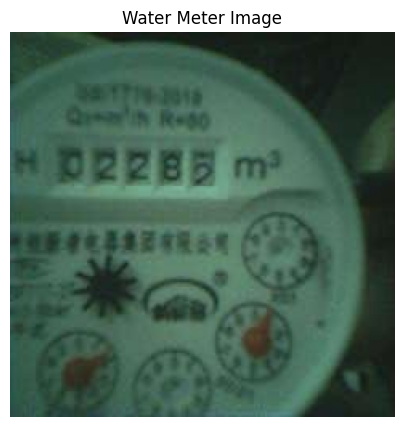

Image shape: (240, 240, 3)


In [8]:
import cv2
import matplotlib.pyplot as plt

# Pick the first image from train
img_path = "analog-meter-water-1/train/images/1683618660-8624434_png_jpg.rf.3bf8237db131225acbb19c6e9b50d20b.jpg"

img = cv2.imread(img_path)

# Remember: cv2 = BGR, matplotlib = RGB, so we convert
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 5))
plt.imshow(img_rgb)
plt.title("Water Meter Image")
plt.axis("off")
plt.show()

print(f"Image shape: {img.shape}")  # (height, width, 3)

In [9]:
with open("analog-meter-water-1/data.yaml", "r") as f:
    print(f.read())

names:
- '0'
- '1'
- '2'
- '3'
- '4'
- '5'
- '6'
- '7'
- '8'
- '9'
- N
nc: 11
roboflow:
  license: MIT
  project: digital-meter-water
  url: https://universe.roboflow.com/seeed-studio-dbk14/digital-meter-water/dataset/1
  version: 1
  workspace: seeed-studio-dbk14
test: ../test/images
train: ../train/images
val: ../valid/images



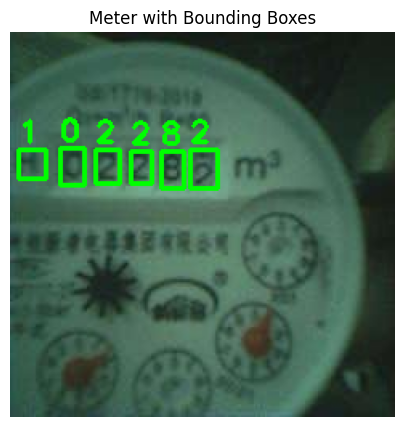

In [10]:
import cv2
import matplotlib.pyplot as plt

# class names from data.yaml
class_names = ['0','1','2','3','4','5','6','7','8','9','N']

img_path = "analog-meter-water-1/train/images/1683618660-8624434_png_jpg.rf.3bf8237db131225acbb19c6e9b50d20b.jpg"
lbl_path = "analog-meter-water-1/train/labels/1683618660-8624434_png_jpg.rf.3bf8237db131225acbb19c6e9b50d20b.txt"

img = cv2.imread(img_path)
h, w = img.shape[:2]  # get height and width of the image

# Read label file
with open(lbl_path, "r") as f:
    lines = f.readlines()

# Draw each bounding box
for line in lines:
    parts = line.strip().split()
    class_id = int(parts[0])         # which digit (0-9 or N)
    x_center = float(parts[1]) * w   # convert from fraction → pixels
    y_center = float(parts[2]) * h
    bw       = float(parts[3]) * w   # box width in pixels
    bh       = float(parts[4]) * h   # box height in pixels

    # Calculate top-left and bottom-right corners of the box
    x1 = int(x_center - bw / 2)
    y1 = int(y_center - bh / 2)
    x2 = int(x_center + bw / 2)
    y2 = int(y_center + bh / 2)

    # Draw rectangle and label
    cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(img, class_names[class_id], (x1, y1 - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(8, 5))
plt.imshow(img_rgb)
plt.title("Meter with Bounding Boxes")
plt.axis("off")
plt.show()

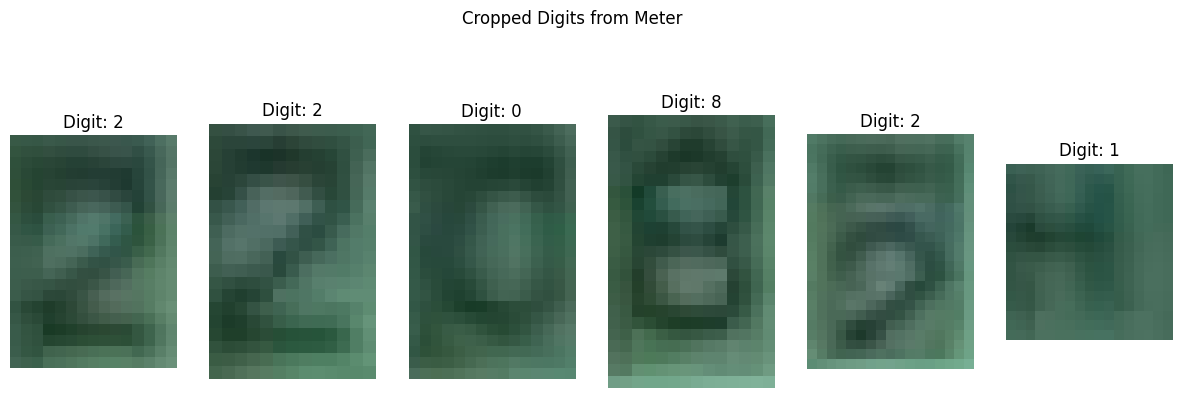

In [12]:
import cv2
import matplotlib.pyplot as plt

class_names = ['0','1','2','3','4','5','6','7','8','9','N']

img_path = "analog-meter-water-1/train/images/1683618660-8624434_png_jpg.rf.3bf8237db131225acbb19c6e9b50d20b.jpg"
lbl_path = "analog-meter-water-1/train/labels/1683618660-8624434_png_jpg.rf.3bf8237db131225acbb19c6e9b50d20b.txt"

img = cv2.imread(img_path)
h, w = img.shape[:2]

with open(lbl_path, "r") as f:
    lines = f.readlines()

crops = []  # list to store each cropped digit

for line in lines:
    parts = line.strip().split()
    class_id = int(parts[0])
    x_center = float(parts[1]) * w
    y_center = float(parts[2]) * h
    bw       = float(parts[3]) * w
    bh       = float(parts[4]) * h

    x1 = int(x_center - bw / 2)
    y1 = int(y_center - bh / 2)
    x2 = int(x_center + bw / 2)
    y2 = int(y_center + bh / 2)

    # ✂️ Crop just this digit from the image
    crop = img[y1:y2, x1:x2]
    crops.append((class_names[class_id], crop))

# Display all cropped digits side by side
fig, axes = plt.subplots(1, len(crops), figsize=(15, 5))
for i, (label, crop) in enumerate(crops):
    crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
    axes[i].imshow(crop_rgb)
    axes[i].set_title(f"Digit: {label}")
    axes[i].axis("off")

plt.suptitle("Cropped Digits from Meter")
plt.show()

Meter Reading: 102282


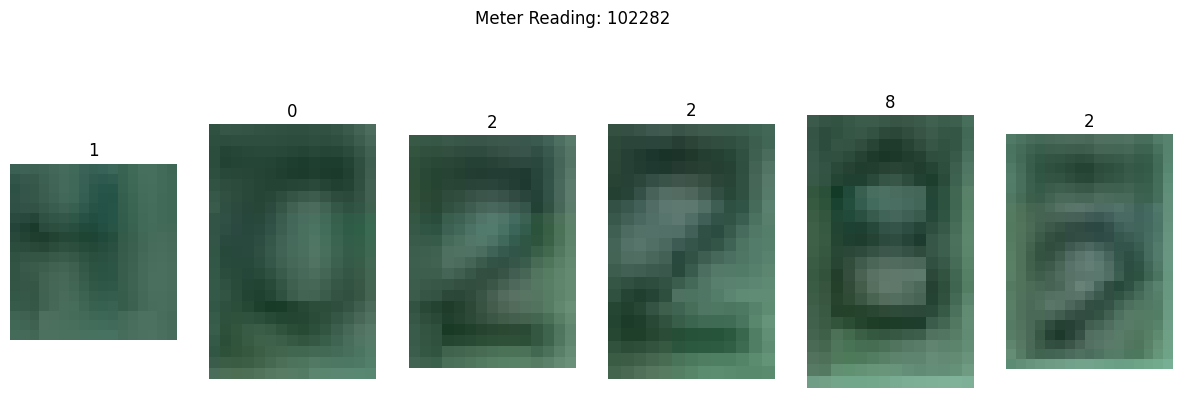

In [14]:
crops_with_pos = []

for line in lines:
    parts = line.strip().split()
    class_id = int(parts[0])
    x_center = float(parts[1]) * w
    y_center = float(parts[2]) * h
    bw       = float(parts[3]) * w
    bh       = float(parts[4]) * h

    x1 = int(x_center - bw / 2)
    y1 = int(y_center - bh / 2)
    x2 = int(x_center + bw / 2)
    y2 = int(y_center + bh / 2)

    crop = img[y1:y2, x1:x2]

    # Save x_center too so we can sort later
    crops_with_pos.append((x_center, class_names[class_id], crop))

# Sort left → right by x position
crops_with_pos.sort(key=lambda item: item[0])

# Read the full meter number
full_reading = ''.join([label for _, label, _ in crops_with_pos])
print(f"Meter Reading: {full_reading}")

# Display sorted
fig, axes = plt.subplots(1, len(crops_with_pos), figsize=(15, 5))
for i, (_, label, crop) in enumerate(crops_with_pos):
    crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
    axes[i].imshow(crop_rgb)
    axes[i].set_title(f"{label}")
    axes[i].axis("off")

plt.suptitle(f"Meter Reading: {full_reading}")
plt.show()

In [15]:
import os

# Path to all images and labels
images_dir = "analog-meter-water-1/train/images/"
labels_dir = "analog-meter-water-1/train/labels/"

class_names = ['0','1','2','3','4','5','6','7','8','9','N']

all_readings = []  # list to store all results

# Loop on every image in the folder
for img_file in os.listdir(images_dir):

    # Build full path for image and its label
    img_path = os.path.join(images_dir, img_file)
    lbl_path = os.path.join(labels_dir, img_file.replace(".jpg", ".txt"))

    # Skip if label file doesn't exist
    if not os.path.exists(lbl_path):
        continue

    # Load image
    img = cv2.imread(img_path)
    h, w = img.shape[:2]

    # Read labels
    with open(lbl_path, "r") as f:
        lines = f.readlines()

    crops_with_pos = []

    for line in lines:
        parts = line.strip().split()
        class_id = int(parts[0])
        x_center = float(parts[1]) * w
        y_center = float(parts[2]) * h
        bw       = float(parts[3]) * w
        bh       = float(parts[4]) * h

        x1 = int(x_center - bw / 2)
        y1 = int(y_center - bh / 2)
        x2 = int(x_center + bw / 2)
        y2 = int(y_center + bh / 2)

        crop = img[y1:y2, x1:x2]
        crops_with_pos.append((x_center, class_names[class_id], crop))

    # Sort left → right
    crops_with_pos.sort(key=lambda item: item[0])

    # Build full reading
    full_reading = ''.join([label for _, label, _ in crops_with_pos])

    all_readings.append({
        "image": img_file,
        "reading": full_reading
    })

# Print all results
print(f"Total images processed: {len(all_readings)}\n")
for r in all_readings[:10]:  # show first 10 only
    print(f"📊 {r['image'][:30]}...  →  Reading: {r['reading']}")

Total images processed: 2550

📊 1683619316-755082_png_jpg.rf.a...  →  Reading: 04021
📊 1683617998-3307474_png_jpg.rf....  →  Reading: 02102
📊 1683619023-1455045_png_jpg.rf....  →  Reading: 02835
📊 1683619637-777348_png_jpg.rf.5...  →  Reading: 05003
📊 1683618079-98218_png_jpg.rf.f6...  →  Reading: 02NNN
📊 1683617780-4007423_png_jpg.rf....  →  Reading: 0170N
📊 1683618883-0066903_png_jpg.rf....  →  Reading: 0261N
📊 1683619319-279659_png_jpg.rf.3...  →  Reading: 04023
📊 1683618674-021483_png_jpg.rf.c...  →  Reading: 02294
📊 1683618781-1698408_png_jpg.rf....  →  Reading: 02431


In [16]:
total = len(all_readings)

# Count readings with N (unclear digits)
with_N = [r for r in all_readings if 'N' in r['reading']]

# Count clean readings (no N)
clean = [r for r in all_readings if 'N' not in r['reading']]

print(f"Total images:       {total}")
print(f"Clean readings:     {len(clean)}  ({len(clean)/total*100:.1f}%)")
print(f"Readings with N:    {len(with_N)}  ({len(with_N)/total*100:.1f}%)")

Total images:       2550
Clean readings:     1916  (75.1%)
Readings with N:    634  (24.9%)


In [17]:
import requests
import json
import datetime

# Take one clean reading to test
test_reading = clean[0]

# Build the JSON payload
payload = {
    "meter_id":  "WM-HOME-001",
    "reading":   test_reading['reading'],
    "unit":      "m3",
    "timestamp": datetime.datetime.now().isoformat(),
    "source":    "image_ocr",
    "image":     test_reading['image'],
    "status":    "ok"
}

print("📦 Payload we are sending:")
print(json.dumps(payload, indent=2))

# Send to test server
response = requests.post(
    "https://jsonplaceholder.typicode.com/posts",
    json=payload
)

print(f"\n📡 Server response status: {response.status_code}")
print(f"📥 Server response:")
print(json.dumps(response.json(), indent=2))

📦 Payload we are sending:
{
  "meter_id": "WM-HOME-001",
  "reading": "04021",
  "unit": "m3",
  "timestamp": "2026-03-09T21:06:01.435596",
  "source": "image_ocr",
  "image": "1683619316-755082_png_jpg.rf.a649194fcdc00700e5d4a3a5a66bd32f.jpg",
  "status": "ok"
}

📡 Server response status: 201
📥 Server response:
{
  "meter_id": "WM-HOME-001",
  "reading": "04021",
  "unit": "m3",
  "timestamp": "2026-03-09T21:06:01.435596",
  "source": "image_ocr",
  "image": "1683619316-755082_png_jpg.rf.a649194fcdc00700e5d4a3a5a66bd32f.jpg",
  "status": "ok",
  "id": 101
}
